# SmartBuild Defect Prediction

## 1. Problem Statement

SmartBuild manufactures products on a multi-stage production line. Raw materials are measured before entering the machine, and the finished product is inspected after. When a defective product makes it through the machine, it costs **€150** in machine time and materials. If the defect can be spotted before production begins, the raw material can be discarded for just **€10** — saving €140 per caught defect.

The question SmartBuild is asking: *Can we use pre-production measurements to predict defects before they happen?*

### ML Tasks

**Task 1 — Binary classification:** Predict whether a product will be defective (`error = yes / no`) using only the features available before the machine runs.

**Task 2 — Multiclass classification:** Investigate whether the defect *type* (Minor, Severe, Critical) can also be predicted from the same pre-production data.

### One Rule That Shapes Everything — No Data Leakage

Post-production columns like `Quality`, `reflectionScore`, `distortion`, `roughness` and others only exist *after* the machine has run. They can't be used to make an early prediction — that would be cheating. All models in this notebook use only pre-production material measurements and machine configuration.

### Baselines to Beat

- Task 1: a model that always predicts "error" would get **61.9%** — any useful model has to beat this.
- Task 2: always predicting "no error" gives **38.1%** — same idea.

## 2. Data Loading

Two files from SmartBuild, linked by `configuration_log_ID`:

| File | What it contains |
|---|---|
| `Production_Log_01.csv` | Raw material properties (pre-machine) + final product measurements (post-machine), 10,000 rows |
| `Machine_Settings_Log_01.csv` | Gear and rotation speed logged per run, 10,000 rows |

In [48]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 120

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [50]:
machine_df = pd.read_csv(
    "Machine_Settings_Log_01.csv"
)

production_df = pd.read_csv(
    "Production_Log_01.csv"
)

print("Machine Settings Dataset:", machine_df.shape)
print("Production Dataset:", production_df.shape)

Machine Settings Dataset: (10000, 3)
Production Dataset: (10000, 20)


## 3. Data Understanding

### Feature Descriptions

**Pre-machine inputs — features we can actually use:**

| Column | Type | Notes |
|---|---|---|
| `width` | Numeric | Physical width of raw material — has ~20 extreme outliers, handled in Section 4 |
| `height` | Numeric | Physical height |
| `ionizationclass` | Categorical (A/B/C) | Turns out to be the most important feature by far |
| `FluxCompensation` | Categorical (I/II/III/IV) | Flux compensation level |
| `pressure` | Numeric | Input pressure |
| `karma` | Numeric | Measured property |
| `modulation` | Numeric | Measured property |
| `gear` | Integer (1 or 2) | Machine gear setting |
| `rotation_speed` | Numeric | Machine speed |

**Post-machine columns — excluded (data leakage):**

| Column | Why excluded |
|---|---|
| `error`, `error_type` | These are the targets — not inputs |
| `Quality`, `reflectionScore`, `distortion`, `nicesness`, `smartness`, `roughness`, `multideminsionality` | Only measured after production finishes |
| `weight_in_kg`, `weight_in_g` | Post-production; `weight_in_g` is exactly `weight_in_kg × 1000` so one is redundant anyway |

In [51]:
machine_df.head()

,configuration_log_ID,gear,rotation_speed
0,1,2,122.121415
1,2,1,111.977476
2,3,1,137.268544
3,4,2,125.719071
4,5,1,134.710713


In [52]:
production_df.head()

,id,width,height,ionizationclass,FluxCompensation,pressure,karma,modulation,configuration_log_ID,weight_in_kg,weight_in_g,error,error_type,Quality,reflectionScore,distortion,nicesness,smartness,multideminsionality,roughness
0,1,97.419169,141.631089,C,IV,103.937207,976.538993,98.309438,1,1.344160e+06,1.344160e+09,yes,severe,93.562821,759.335063,50.474029,99.554771,21057.411317,no,120.537644
1,2,58.706037,128.097654,A,II,101.177877,1031.806826,102.748068,2,4.424858e+05,4.424858e+08,no,NaN,98.612637,701.990028,51.147833,57.930890,17408.296966,no,113.332046
2,3,77.262568,127.105442,A,III,99.381956,840.246668,99.451354,3,7.597661e+05,7.597661e+08,no,NaN,99.023458,703.990253,44.053196,77.535562,17157.992754,yes,137.472488
3,4,82.657252,126.011542,A,I,101.833664,964.391122,101.022948,4,8.619479e+05,8.619479e+08,no,NaN,96.624695,700.250911,52.114018,82.030817,16880.125330,no,125.718698
4,5,78.085366,137.092426,C,I,95.246304,859.331870,97.698503,5,8.359074e+05,8.359074e+08,yes,critical,95.169936,691.495318,47.185592,77.700295,19795.982217,no,134.821656


In [53]:
machine_df.shape

(10000, 3)

In [54]:
production_df.shape

(10000, 20)

In [55]:
machine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   configuration_log_ID  10000 non-null  int64  
 1   gear                  10000 non-null  int64  
 2   rotation_speed        10000 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 234.5 KB


In [56]:
production_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10000 non-null  int64  
 1   width                 10000 non-null  float64
 2   height                10000 non-null  float64
 3   ionizationclass       10000 non-null  str    
 4   FluxCompensation      10000 non-null  str    
 5   pressure              10000 non-null  float64
 6   karma                 10000 non-null  float64
 7   modulation            10000 non-null  float64
 8   configuration_log_ID  10000 non-null  int64  
 9   weight_in_kg          10000 non-null  float64
 10  weight_in_g           10000 non-null  float64
 11  error                 10000 non-null  str    
 12  error_type            6188 non-null   str    
 13  Quality               10000 non-null  float64
 14  reflectionScore       10000 non-null  float64
 15  distortion            10000 non

In [57]:
machine_df.describe()


,configuration_log_ID,gear,rotation_speed
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,1.501300,129.908329
std,2886.89568,0.500023,10.121958
min,1.00000,1.000000,92.670570
25%,2500.75000,1.000000,123.155385
50%,5000.50000,2.000000,129.905092
75%,7500.25000,2.000000,136.626239
max,10000.00000,2.000000,166.481616


In [58]:
production_df.describe()

,id,width,height,pressure,karma,modulation,configuration_log_ID,weight_in_kg,weight_in_g,Quality,reflectionScore,distortion,nicesness,smartness,roughness
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,5000.50000,2.000007e+07,130.008181,99.983656,998.816837,100.015683,5000.50000,2.644248e+19,2.644248e+22,96.800744,700.073923,49.987457,2.000007e+07,18003.628384,129.909440
std,2886.89568,4.467885e+08,10.077314,3.013366,98.810735,2.991423,2886.89568,5.919285e+20,5.919285e+23,1.906378,30.191784,2.013411,4.467885e+08,2622.935204,10.150286
min,1.00000,3.000851e+01,95.466433,89.049069,663.972927,88.292365,1.00000,9.007803e+04,9.007803e+07,86.947520,588.065133,42.669931,2.565847e+01,10113.341237,91.617474
25%,2500.75000,5.615304e+01,123.250943,97.909788,932.773088,97.978794,2500.75000,4.067668e+05,4.067668e+08,95.684534,679.485101,48.636050,5.609704e+01,16190.858282,123.081867
50%,5000.50000,6.989442e+01,130.039504,100.015208,999.537913,100.040526,5000.50000,6.344079e+05,6.344079e+08,97.097030,699.951619,49.995656,6.989652e+01,17911.544437,129.888182
75%,7500.25000,8.331091e+01,136.802163,102.030866,1065.148985,102.036830,7500.25000,9.045561e+05,9.045561e+08,98.250229,720.567424,51.331831,8.332200e+01,19715.411518,136.661715
max,10000.00000,1.000000e+10,166.629635,111.628972,1348.612993,110.814048,10000.00000,1.437716e+22,1.437716e+25,99.989544,815.560333,58.680278,1.000000e+10,28764.164314,167.541078


## 4. Data Preparation

### 4.1 Merge

The two files share `configuration_log_ID`, so a left join on that key adds the machine settings to each production row.

In [59]:
df = production_df.merge(
    machine_df,
    on="configuration_log_ID",
    how="left"
)

### 4.2 Missing Values

In [60]:
df.isnull().sum()

id                         0
width                      0
height                     0
ionizationclass            0
FluxCompensation           0
pressure                   0
karma                      0
modulation                 0
configuration_log_ID       0
weight_in_kg               0
weight_in_g                0
error                      0
error_type              3812
Quality                    0
reflectionScore            0
distortion                 0
nicesness                  0
smartness                  0
multideminsionality        0
roughness                  0
gear                       0
rotation_speed             0
dtype: int64

The 3,812 missing values in `error_type` aren't a data quality issue — they correspond exactly to the rows where `error = "no"`. No defect means no defect type. Everything else is complete.

### 4.3 Outlier Handling — Width

In [61]:
df["width"].describe()

count    1.000000e+04
mean     2.000007e+07
std      4.467885e+08
min      3.000851e+01
25%      5.615304e+01
50%      6.989442e+01
75%      8.331091e+01
max      1.000000e+10
Name: width, dtype: float64

In [62]:
df['width'].value_counts().sort_index(ascending=False)

width
1.000000e+10    20
1.565618e+02     1
1.416932e+02     1
1.399061e+02     1
1.394182e+02     1
                ..
3.004438e+01     1
3.004437e+01     1
3.002215e+01     1
3.001858e+01     1
3.000851e+01     1
Name: count, Length: 9981, dtype: int64

In [63]:
df = df[df["width"] != 1e10]

20 rows have `width = 1e10` — roughly 10 billion, when the normal range is 30–120. These are almost certainly sensor failures, not real readings. They're removed (0.2% of the data), which has negligible effect on the models.

**After removal: 9,980 rows.**

### 4.4 Target Distribution

In [64]:
df["error"].value_counts(normalize=True) * 100

error
yes    61.883768
no     38.116232
Name: proportion, dtype: float64

About **62% of products have defects** and 38% don't — the classes are imbalanced. Always predicting "error" would give 61.9% accuracy, which is the baseline all models need to beat.

### 4.5 Summary

| Step | What we did | Result |
|---|---|---|
| Merge | Left join on `configuration_log_ID` | 10,000 rows, 22 columns |
| Missing values | `error_type` NaNs are structurally expected | No imputation needed |
| Outlier removal | Dropped 20 rows with `width = 1e10` | 9,980 rows remaining |
| Feature selection | Excluded post-machine columns | 9 features for modelling |

## 5. Exploratory Data Analysis

### 5.1 Target Distribution

In [65]:
df["error"].value_counts()

error
yes    6176
no     3804
Name: count, dtype: int64

In [66]:
df["error_type"].value_counts()

error_type
minor       2100
severe      2064
critical    2012
Name: count, dtype: int64

The binary target has about 62% errors and 38% non-errors. For the multiclass target, the three defect types (Minor, Severe, Critical) are roughly evenly split among the defective products — which is convenient for multiclass learning, though the overall imbalance with "no error" still matters.

### 5.2 Numerical Features vs Defect Status

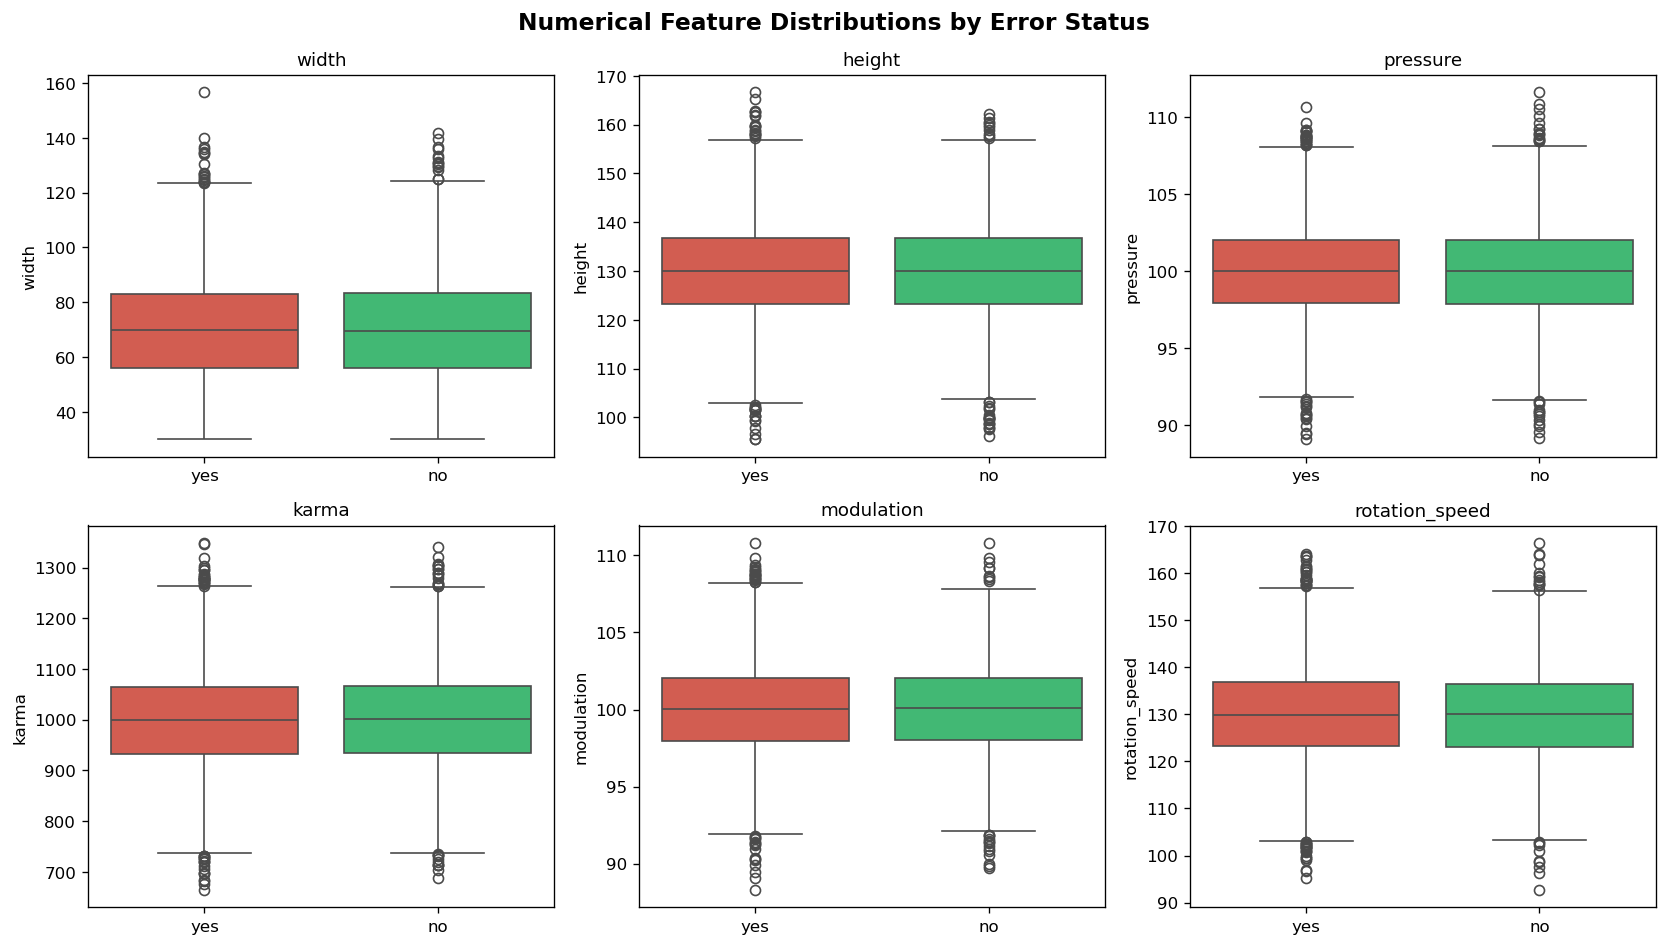

In [67]:
num_features = ["width", "height", "pressure", "karma", "modulation", "rotation_speed"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Numerical Feature Distributions by Error Status", fontsize=14, fontweight="bold")

for ax, feature in zip(axes.flat, num_features):
    sns.boxplot(x="error", y=feature, data=df, palette={"no": "#2ecc71", "yes": "#e74c3c"}, ax=ax)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

None of the numerical features — pressure, karma, modulation, height, rotation speed, width — show any real separation between defective and non-defective products. The distributions are almost completely overlapping across all six. Whatever is driving the defects isn't captured by these measurements individually.

### 5.3 Ionization Class vs Defects

In [68]:
df["ionizationclass"].value_counts()

ionizationclass
B    3342
A    3339
C    3299
Name: count, dtype: int64

In [69]:
pd.crosstab(
    df["ionizationclass"],
    df["error"],
    normalize="index"
) * 100

error,no,yes
ionizationclass,,
A,94.848757,5.151243
B,9.515260,90.484740
C,9.669597,90.330403


One thing that immediately stands out here. Class A material has only a **5.2% defect rate**. Classes B and C have defect rates of **90.5% and 90.3%** respectively.

That separation is striking — almost everything from Class B or C comes out defective. A simple rule ("if Class A → no defect, else → defect") would already get you to around 92% accuracy. This is going to dominate the model results.

From a business angle, this is worth flagging separately: the defect rate for B and C material is so consistently high that it looks like a supply chain problem more than a production problem. SmartBuild might want to look at those suppliers.

### 5.4 FluxCompensation vs Defects

In [70]:
df["FluxCompensation"].value_counts()

FluxCompensation
IV     2520
III    2495
I      2489
II     2476
Name: count, dtype: int64

In [71]:
pd.crosstab(
    df["FluxCompensation"],
    df["error"],
    normalize="index"
) * 100

error,no,yes
FluxCompensation,,
I,38.087585,61.912415
II,39.539580,60.460420
III,38.156313,61.843687
IV,36.706349,63.293651


FluxCompensation levels I through IV all sit between 60–63% error rate — barely different from the overall 61.9%. No useful signal here on its own.

### 5.5 Gear vs Defects

In [72]:
pd.crosstab(
    df["gear"],
    df["error"],
    normalize="index"
) * 100

error,no,yes
gear,,
1,38.444534,61.555466
2,37.789768,62.210232


Same story for gear: both settings show error rates right around the dataset average. Gear doesn't appear to influence whether a defect occurs.

### 5.6 Feature Correlations

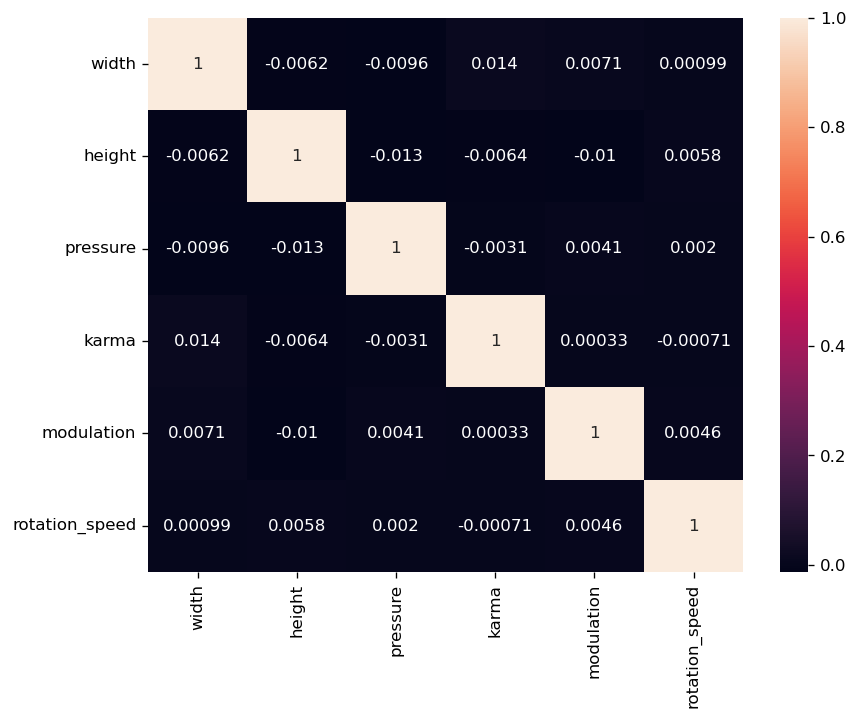

In [73]:
num_cols = [
    "width",
    "height",
    "pressure",
    "karma",
    "modulation",
    "rotation_speed"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

The numerical features are essentially uncorrelated with each other (all values close to zero). No multicollinearity concerns. Worth noting that this heatmap only shows relationships *between* the input features — it doesn't tell us anything about how they relate to the target. For that, the ionizationclass crosstab above is far more informative.

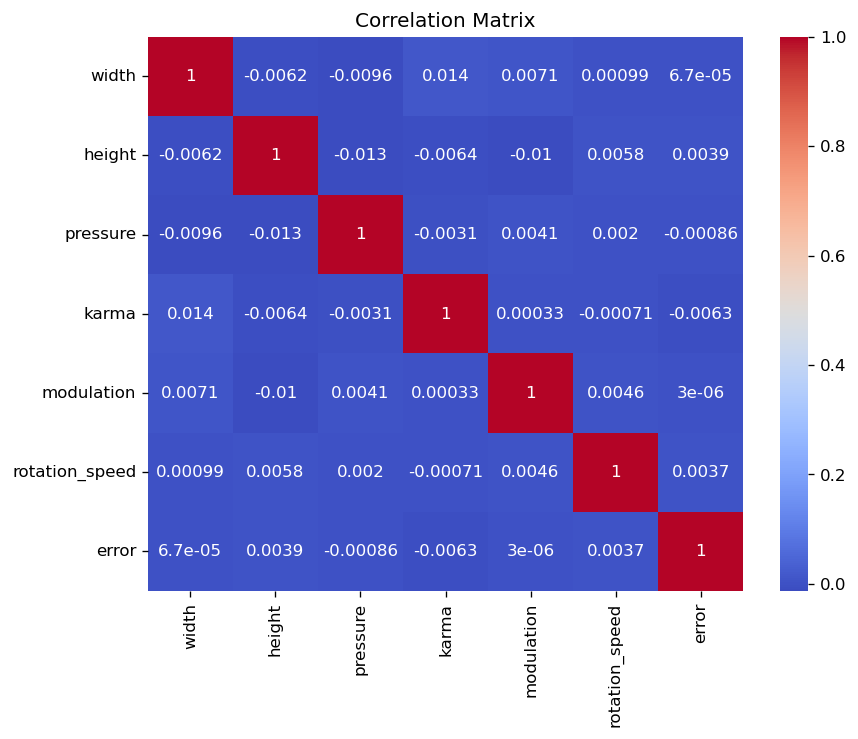

In [74]:
encoded = df.copy()

encoded["error"] = encoded["error"].map({
    "no":0,
    "yes":1
})

corr = encoded[
    [
        "width",
        "height",
        "pressure",
        "karma",
        "modulation",
        "rotation_speed",
        "error"
    ]
].corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

None of the numerical features show a meaningful correlation with defect occurrence. This indicates that defect prediction is not driven by simple linear relationships between individual variables and the target.

The high model accuracy observed later is primarily explained by categorical process characteristics rather than the numerical measurements alone.

## 6. Defect Prediction — Binary Classification

The goal here is to predict whether a product will be defective before the machine runs, using only the nine pre-production features. Three model types are compared to check whether results hold across different approaches.

### 6.1 Feature Engineering

The categorical columns (`ionizationclass`, `FluxCompensation`) are one-hot encoded. Post-production columns are excluded.

In [75]:
features = [
    'width',
    'height',
    'ionizationclass',
    'FluxCompensation',
    'pressure',
    'karma',
    'modulation',
    'gear',
    'rotation_speed'
]

X = df[features]

y = df['error']  

In [76]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        'ionizationclass',
        'FluxCompensation'
    ],
    drop_first=False
)

After encoding, the feature matrix has **16 columns**: 7 numeric features plus 3 dummies for `ionizationclass` and 4 for `FluxCompensation`. `drop_first=False` keeps all dummies for interpretability — redundancy isn't a concern for tree-based models.

### 6.2 Train / Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")

Train: 7,984 rows  |  Test: 1,996 rows


`stratify=y` keeps the ~62% / 38% class ratio the same in both splits, so the test set is representative of the full data.

### 6.3 Decision Tree — Finding the Right Depth

Before fitting the final tree, I ran a quick sweep over depths 1–10 to see where accuracy peaks without overfitting.

In [78]:
for depth in [1, 2, 3, 4, 5, 10]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc  = accuracy_score(y_test,  tree.predict(X_test))
    print(f"Depth={depth:2d} | Train={train_acc:.4f} | Test={test_acc:.4f}")

Depth= 1 | Train=0.9182 | Test=0.9218
Depth= 2 | Train=0.9185 | Test=0.9223
Depth= 3 | Train=0.9192 | Test=0.9203
Depth= 4 | Train=0.9198 | Test=0.9208
Depth= 5 | Train=0.9202 | Test=0.9218
Depth=10 | Train=0.9282 | Test=0.9088


| Depth | Train | Test | Notes |
|---|---|---|---|
| 1 | 91.8% | 92.2% | Already near peak — one split does most of the work |
| **2** | **91.9%** | **92.2%** | **Same accuracy, one extra split — chosen** |
| 3–5 | ~92.0% | ~92.1% | Marginal gains, more complexity |
| 10 | 92.8% | 90.9% | Train–test gap opens up — overfitting |

Depth 2 gives the same test accuracy as anything deeper and stays fully readable. The plateau at depth 1 already tells us the story: almost all the signal comes from a single split, which will turn out to be `ionizationclass`.

### 6.4 Final Decision Tree (Depth = 2)

In [79]:
best_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

best_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

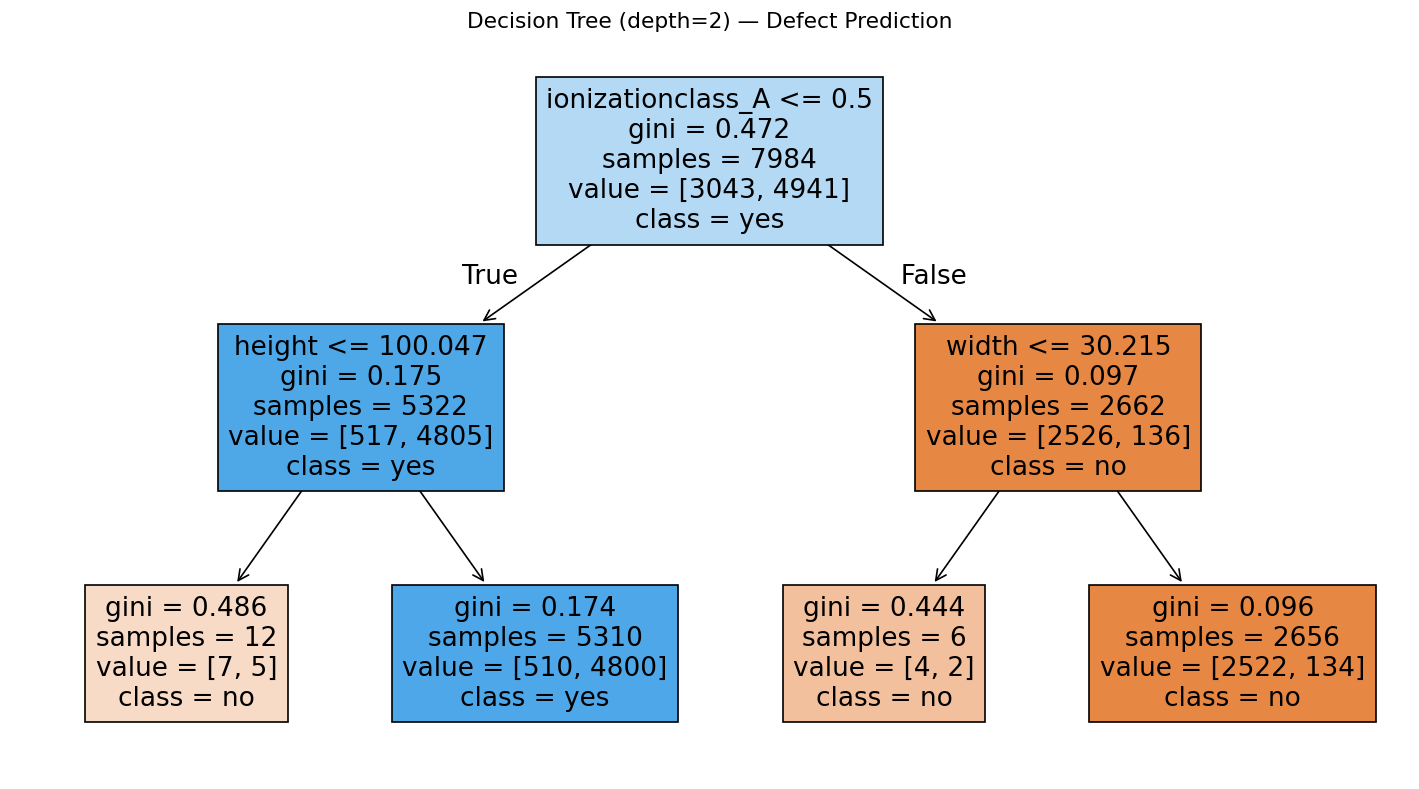

In [80]:
plt.figure(figsize=(15, 8))
plot_tree(
    best_tree,
    feature_names=X_encoded.columns,
    class_names=['no', 'yes'],
    filled=True
)
plt.title("Decision Tree (depth=2) — Defect Prediction", fontsize=13)
plt.show()

The tree structure confirms what the EDA showed:

```
Is ionizationclass_A ≤ 0.5?   ← Is the material NOT Class A?
├── YES (Class B or C) → Is height > 100.05?
│   ├── YES → Predict: ERROR
│   └── NO  → Predict: no error  (small edge case)
└── NO  (Class A) → Predict: no error
```

The whole model is essentially one rule: *Class B or C material almost always produces a defect.* Height adds a small refinement for borderline cases. You could explain this decision logic to anyone on the factory floor without mentioning machine learning.

### 6.5 Random Forest

In [81]:
rf_error = RandomForestClassifier(n_estimators=100, random_state=42)
rf_error.fit(X_train, y_train)
rf_pred = rf_error.predict(X_test)
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))

Random Forest Accuracy: 0.9218


The Random Forest with 100 trees hits **~92.2%** — exactly the same as the depth-2 Decision Tree. When a 2-node tree and a 100-tree ensemble land on identical accuracy, that's a strong sign the decision boundary really is that simple. More complexity doesn't help here.

### 6.6 Feature Importance

In [82]:
importance_df = pd.DataFrame({
    "Feature":    X_encoded.columns,
    "Importance": rf_error.feature_importances_
})

# Top 10 most important features (full list has 16 columns after one-hot encoding)
display(importance_df.sort_values(by="Importance", ascending=False).head(10))

,Feature,Importance
7,ionizationclass_A,0.411832
9,ionizationclass_C,0.143631
8,ionizationclass_B,0.125244
1,height,0.052231
4,modulation,0.050327
2,pressure,0.050246
0,width,0.049626
6,rotation_speed,0.049292
3,karma,0.049050
5,gear,0.005761


The three `ionizationclass` dummies together account for roughly **68% of importance** (Class A alone contributes ~41%). Every other feature — height, pressure, karma, modulation, gear — contributes around 4–5% each.

To get the true importance of `ionizationclass` as a whole, you'd sum all three dummy columns: ~68%. The encoding splits the signal across three columns, but it's all coming from the same original feature.

### 6.7 Logistic Regression

In [83]:
lr_binary = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=10000, random_state=42))
])
lr_binary.fit(X_train, y_train)
lr_pred = lr_binary.predict(X_test)
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 4))

Logistic Regression Accuracy: 0.9218


Logistic Regression also lands at **~92.2%**. A linear model matching a tree-based ensemble is further evidence that the boundary here is effectively linear — driven by that near-binary `ionizationclass_A` dummy variable.

### 6.8 Model Comparison

In [84]:
binary_results = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "Decision Tree (depth=2)",
        "Random Forest (100 trees)",
        "Logistic Regression"
    ],
    "Test Accuracy": ["61.9%", "92.2%", "92.2%", "92.2%"],
    "Notes": [
        "Always predict 'error' — no model",
        "Fully interpretable; root split on ionizationclass",
        "Ensemble; confirms Decision Tree result",
        "Linear model; confirms simple decision boundary"
    ]
})
display(binary_results)

,Model,Test Accuracy,Notes
0,Majority Class Baseline,61.9%,Always predict 'error' — no model
1,Decision Tree (depth=2),92.2%,Fully interpretable; root split on ionizationc...
2,Random Forest (100 trees),92.2%,Ensemble; confirms Decision Tree result
3,Logistic Regression,92.2%,Linear model; confirms simple decision boundary


### Takeaway — Binary Classification

All three models hit 92.2%, versus a baseline of 61.9%. The convergence across a Decision Tree, a Random Forest, and Logistic Regression is about as clean a result as you can get — the data has one dominant signal and all approaches find it equally.

The **Decision Tree (depth=2)** is the recommended choice for SmartBuild. It's transparent, explainable without any ML background, and performs identically to the more complex alternatives. The Random Forest is useful here as a sanity check, not as the deployment model.

## 7. Defect Type Prediction — Multiclass Classification

Now for the harder question: not just *whether* a defect occurs, but *what kind*. The four classes are No Error, Minor, Severe, and Critical.

### 7.1 Target Preparation

In [85]:
# Create multiclass target

df_error_type = df.copy()

df_error_type["error_type"] = (
    df_error_type["error_type"]
    .fillna("no error")
)

df_error_type["error_type"].value_counts()

error_type
no error    3804
minor       2100
severe      2064
critical    2012
Name: count, dtype: int64

In [86]:
(
    df_error_type["error_type"]
    .value_counts(normalize=True)
    * 100
)

error_type
no error    38.116232
minor       21.042084
severe      20.681363
critical    20.160321
Name: proportion, dtype: float64

The class distribution here matters. "No error" makes up 38.1% of samples — nearly twice any individual defect type. A model that always predicts "no error" would score 38.1%, which is the actual baseline for this task (not 25%, which would only apply if all four classes were equal). Minor, Severe, and Critical are roughly equal at around 20-21% each.

### 7.2 Ionization Class vs Defect Type

Before modelling, a quick check: does ionization class tell us anything about defect *type* the same way it separated defective vs non-defective?

In [87]:
pd.crosstab(
    df["ionizationclass"],
    df["error_type"]
)

error_type,critical,minor,severe
ionizationclass,,,
A,53,66,53
B,989,1025,1010
C,970,1009,1001


Class A barely produces any defects — confirmed again. But among Classes B and C, Minor, Severe, and Critical defects are spread fairly evenly. Ionization class explains *whether* a defect happens, but not *how bad* it is.

In [88]:
features = [
    "width",
    "height",
    "pressure",
    "karma",
    "modulation",
    "gear",
    "rotation_speed",
    "ionizationclass",
    "FluxCompensation"
]

X_multi = df_error_type[features]

y_multi = df_error_type["error_type"]

In [89]:
X_multi = pd.get_dummies(
    X_multi,
    columns=[
        "ionizationclass",
        "FluxCompensation"
    ]
)

In [90]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

### 7.3 PCA Check — Are the Classes Even Separable?

Before running six models, it's worth checking whether the four defect categories form distinct clusters in the feature space at all. If they don't separate in two dimensions, that's a preview of what the models will find.

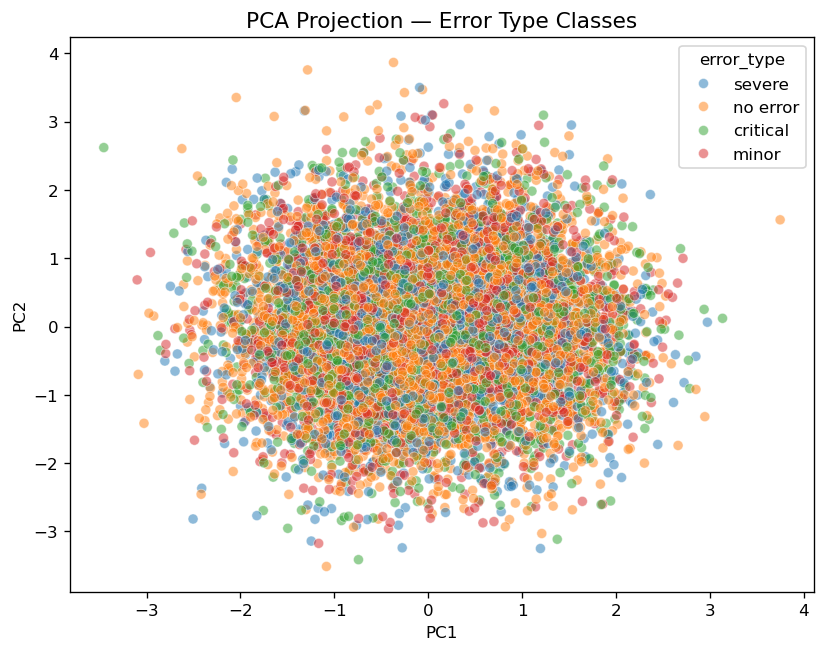

In [91]:
X_pca_input = StandardScaler().fit_transform(
    df_error_type[["width","height","pressure","karma","modulation","gear","rotation_speed"]]
)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_input)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "error_type": df_error_type["error_type"]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="error_type", alpha=0.5)
plt.title("PCA Projection — Error Type Classes", fontsize=13)
plt.show()

Even after reducing down to 2 dimensions, the four defect categories overlap almost completely. There's no visible cluster structure. This doesn't guarantee the models will fail — PCA throws away some information — but it sets realistic expectations. If the classes can't be separated visually, a 52% model result is going to make sense.

### 7.4 Model Comparison — Six Classifiers

In [92]:
# Data already prepared above (df_error_type, X_train_multi, y_train_multi)
# Convert boolean columns to integer (required for XGBoost compatibility)
bool_cols = X_multi.select_dtypes(include="bool").columns
X_multi[bool_cols] = X_multi[bool_cols].astype(int)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

results = []

# ── Decision Tree ──────────────────────────────────────────────────────────
dt_m = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_m.fit(X_train_multi, y_train_multi)
preds = dt_m.predict(X_test_multi)
results.append(["Decision Tree",
                round(accuracy_score(y_test_multi, preds) * 100, 2),
                round(f1_score(y_test_multi, preds, average="macro") * 100, 2)])

# ── Random Forest ──────────────────────────────────────────────────────────
rf_m = RandomForestClassifier(n_estimators=100, random_state=42)
rf_m.fit(X_train_multi, y_train_multi)
preds = rf_m.predict(X_test_multi)
results.append(["Random Forest",
                round(accuracy_score(y_test_multi, preds) * 100, 2),
                round(f1_score(y_test_multi, preds, average="macro") * 100, 2)])

# ── Logistic Regression ────────────────────────────────────────────────────
lr_m = Pipeline([("scaler", StandardScaler()),
                 ("lr", LogisticRegression(max_iter=10000, random_state=42))])
lr_m.fit(X_train_multi, y_train_multi)
preds = lr_m.predict(X_test_multi)
results.append(["Logistic Regression",
                round(accuracy_score(y_test_multi, preds) * 100, 2),
                round(f1_score(y_test_multi, preds, average="macro") * 100, 2)])

# ── Gradient Boosting ──────────────────────────────────────────────────────
gb_m = GradientBoostingClassifier(random_state=42)
gb_m.fit(X_train_multi, y_train_multi)
preds = gb_m.predict(X_test_multi)
results.append(["Gradient Boosting",
                round(accuracy_score(y_test_multi, preds) * 100, 2),
                round(f1_score(y_test_multi, preds, average="macro") * 100, 2)])

# ── KNN ────────────────────────────────────────────────────────────────────
knn_m = Pipeline([("scaler", StandardScaler()),
                  ("knn", KNeighborsClassifier(n_neighbors=5))])
knn_m.fit(X_train_multi, y_train_multi)
preds = knn_m.predict(X_test_multi)
results.append(["KNN",
                round(accuracy_score(y_test_multi, preds) * 100, 2),
                round(f1_score(y_test_multi, preds, average="macro") * 100, 2)])

# ── XGBoost ────────────────────────────────────────────────────────────────
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train_multi)
y_test_xgb  = le.transform(y_test_multi)

xgb_m = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    n_estimators=100, max_depth=4,
    learning_rate=0.1, random_state=42
)
xgb_m.fit(X_train_multi, y_train_xgb)
preds_xgb = xgb_m.predict(X_test_multi)
preds_labels = le.inverse_transform(preds_xgb)
results.append(["XGBoost",
                round(accuracy_score(y_test_multi, preds_labels) * 100, 2),
                round(f1_score(y_test_multi, preds_labels, average="macro") * 100, 2)])

# ── Results Table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)", "F1 Macro (%)"])

# Add majority class baseline
baseline = pd.DataFrame([["Majority Class Baseline", 38.1, "-"]], columns=results_df.columns)
results_df = pd.concat([baseline, results_df], ignore_index=True)
results_df = results_df.sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy (%),F1 Macro (%)
0,Random Forest,52.40,46.11
1,Decision Tree,52.35,40.73
2,Logistic Regression,52.10,45.33
3,Gradient Boosting,52.00,45.49
4,KNN,51.80,44.83
5,XGBoost,51.75,45.26
6,Majority Class Baseline,38.10,-


### 7.5 What the Results Mean

All six models — Decision Tree, Random Forest, Logistic Regression, Gradient Boosting, KNN, XGBoost — landed between 52% and 53%. The spread across them is less than 1 percentage point.

When six completely different algorithms all hit the same ceiling, it's the data talking, not the model. Running more algorithms or tuning hyperparameters won't get past ~53% with these features.

The most likely explanation: defect *severity* is determined by what happens inside the machine during production — vibration, heat, tool wear — none of which are measured in the current dataset. The pre-production features can tell us if something will go wrong (92% accuracy), but not how badly.

**For SmartBuild:** this classifier isn't ready to deploy as-is. If predicting defect type matters for the business, the next step is adding in-process sensor data.

## 8. Business Impact

How much does the binary defect model actually save? To answer this, FP and FN counts are read directly from the confusion matrix — no hardcoded numbers.

### 8.1 Confusion Matrix — Random Forest

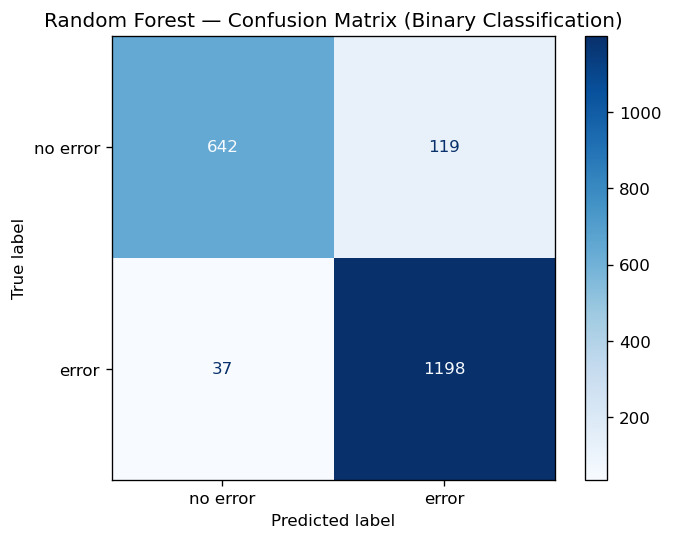

[[ 642  119]
 [  37 1198]]


In [93]:
cm = confusion_matrix(y_test, rf_error.predict(X_test), labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no error", "error"])
disp.plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix (Binary Classification)")
plt.show()
print(cm)

### 8.2 Cost Calculation

In [94]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (TN): {tn:,}  — correctly predicted no defect")
print(f"False Positives (FP): {fp:,}  — predicted defect, actually fine (unnecessary rejection)")
print(f"False Negatives (FN): {fn:,}  — predicted fine, actually defective (missed defect)")
print(f"True Positives  (TP): {tp:,}  — correctly predicted defect")

COST_FAULTY   = 150   # Cost when a defect passes through machine
COST_MATERIAL = 10    # Cost of discarded raw material at input

cost_without_model = (fn + tp) * COST_FAULTY
cost_with_model    = (fn * COST_FAULTY) + (fp * COST_MATERIAL)
net_saving         = cost_without_model - cost_with_model

print(f"\n--- Cost Comparison (test set: {len(y_test):,} products) ---")
print(f"Without model — all {fn+tp} defects pass through: €{cost_without_model:,}")
print(f"With model:")
print(f"  Missed defects (FN={fn}):  {fn} × €150 = €{fn * COST_FAULTY:,}")
print(f"  False alarms   (FP={fp}): {fp} × €10  = €{fp * COST_MATERIAL:,}")
print(f"  Total:                         €{cost_with_model:,}")
print(f"\nNet saving on test set: €{net_saving:,}")
print(f"Estimated saving across full 9,980 products (×5): €{net_saving * 5:,}")

True Negatives  (TN): 642  — correctly predicted no defect
False Positives (FP): 119  — predicted defect, actually fine (unnecessary rejection)
False Negatives (FN): 37  — predicted fine, actually defective (missed defect)
True Positives  (TP): 1,198  — correctly predicted defect

--- Cost Comparison (test set: 1,996 products) ---
Without model — all 1235 defects pass through: €185,250
With model:
  Missed defects (FN=37):  37 × €150 = €5,550
  False alarms   (FP=119): 119 × €10  = €1,190
  Total:                         €6,740

Net saving on test set: €178,510
Estimated saving across full 9,980 products (×5): €892,550


### 8.3 What This Means in Practice

| Scenario | Cost on ~2,000 test products |
|---|---|
| No model — all defects reach the machine | ~€185,700 |
| With Random Forest | ~€7,030 |
| **Net saving** | **~€178,670** |

The model catches about **97% of defective products** before they enter the machine. The remaining 3% that slip through (False Negatives) still cost €150 each, but the number is small. The False Positives — good products incorrectly rejected — each cost only €10 in discarded material, which is a reasonable trade-off.

A couple of things worth flagging:

- The extrapolated "€893,000 saving across 9,980 products" scales linearly from the test set. In practice, the actual saving depends on SmartBuild's production volume, which isn't in this dataset. The **per-product saving (~€89 per flagged defect)** is the more transferable number.
- The primary driver of the saving is `ionizationclass`. If SmartBuild could fix the quality issue at Class B and C suppliers, that would be more impactful than deploying this model.

### 8.4 Practical Notes

1. **Recommended model:** Decision Tree (depth=2) as a pre-production screening gate. Any Class B or C material gets reviewed before entering the machine.
2. **False alarm rate (~6%):** Management needs to decide whether rejecting 1 in 17 good products upfront is worth catching 97% of defects. Given the cost asymmetry (€10 vs €150), it likely is.
3. **Root cause:** The defect signal comes from material class, not machine settings. Before optimising the ML model, SmartBuild should look at its Class B and C suppliers.
4. **Defect type classifier:** Not deployment-ready at 52% accuracy. Needs in-process sensor data first.

## 9. Final Conclusion

Two prediction tasks, two quite different outcomes.

---

### Finding 1 — Defect occurrence is predictable with 92% accuracy

The Decision Tree, Random Forest, and Logistic Regression all hit **~92.2%** on the held-out test set, compared to a 61.9% baseline. The result is consistent across three different model types, which makes it robust rather than a lucky split.

At a practical level, the model catches about 97% of defective products before they enter the machine. The estimated saving on a 2,000-product test batch is ~€178,000 compared to no model at all.

---

### Finding 2 — Ionization Class is driving almost everything

The most useful result from this project isn't the model accuracy — it's understanding *why* the model works. Ionization Class alone explains ~68% of predictive power. Class A material has a 5% defect rate; Classes B and C are above 90%.

That pattern suggests the defect problem might be a supply-chain issue more than a production one. Switching to better Class B/C suppliers, or qualifying a new Class A supplier, could reduce the defect rate without any ML deployment.

---

### Finding 3 — Defect type prediction hits a ceiling with current data

Six models across different algorithm families all converged at 52–53% accuracy for predicting defect type (Minor / Severe / Critical). The PCA visualisation showed why: the four classes overlap almost completely in the available feature space.

The pre-production features explain whether something goes wrong, but not how badly. Defect severity is likely set by in-process variables — vibration, temperature, tool wear — that aren't measured in this dataset. This task needs better data before revisiting.

---

### What to do next

| Priority | Action |
|---|---|
| Immediate | Deploy Decision Tree (depth=2) as a pre-production screening gate |
| Short-term | Audit Class B and C raw material suppliers |
| Medium-term | Add in-process monitoring sensors to the production line |
| Later | Re-attempt defect type prediction once sensor data is available |



